# Figure 5 Motif Analysis

This notebook reproduces the analyses and visualizations for Figure 5 in the paper. It focuses on characterizing the discovered sequence motifs (Seqlets) within the generated Synthetic Promoters (SPs). 

The analysis is divided into several key sections:
1.  **Motif Contribution Score Analysis**: Evaluates the importance of each discovered motif using DeepLIFT contribution scores.
2.  **Motif Usage Fraction**: Compares the frequency of motif occurrences between Synthetic Promoters (SPs) and Native Promoters (NPs).
3.  **Motif Co-occurrence Analysis**: Analyzes how frequently pairs of motifs appear together, revealing potential combinatorial regulatory logic.
4.  **Global Motif Distribution Heatmap**: Visualizes the density and distribution of motifs across all generated sequences, sorted by target expression bins.
5.  **Single Promoter Analysis (Case Study)**: Presents a detailed sequence-level architectural analysis of two highly active promoters (SP1482 and SP358).
6.  **Ultra-High Activity Sequences Feature Analysis**: Examines a subset of experimentally verified ultra-high activity SPs to identify specific motif compositional signatures.

In [ ]:
# Unified imports (used across all Python analysis cells below)
import os
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import pearsonr
import h5py
import tensorflow as tf

# Import local utility packages
import utils

# (Optional module) Import dmslogo for sequence logos if used in other scripts
try:
    import dmslogo
except ImportError:
    warnings.warn("dmslogo is not installed. Some sequence logo visualizations may require it.")

warnings.simplefilter(action='ignore', category=FutureWarning)

# --- Set Font to Arial Globally ---
font_path = '/home/xlxiang/miniconda3/ARIAL.TTF'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
else:
    print(f"Font not found at {font_path}. Using default font (sans-serif).")

# Set general plotting parameters
plt.rcParams['font.size'] = 12
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.linewidth'] = 1.5

utils.suppress_tf_warnings()

### 1. Motif Contribution Score Analysis
This section analyzes the contribution scores of discovered motifs within the synthetic promoter sequences.
1.  **Data Loading**: Loads FIMO motif scan results (`fimo_target_seq.tsv`) and pre-calculated contribution scores (`contribution_scores.h5`).
2.  **Calculation**: Calculates the mean contribution score for each of the 13 discovered motifs (Seqlet0-12) by aggregating scores from instances where the motifs appear.
3.  **Visualization**: Generates a heatmap comparing "Canonical motifs" (known plant motifs) vs. "Newly-found motifs", showing their relative importance in the model's decision making.

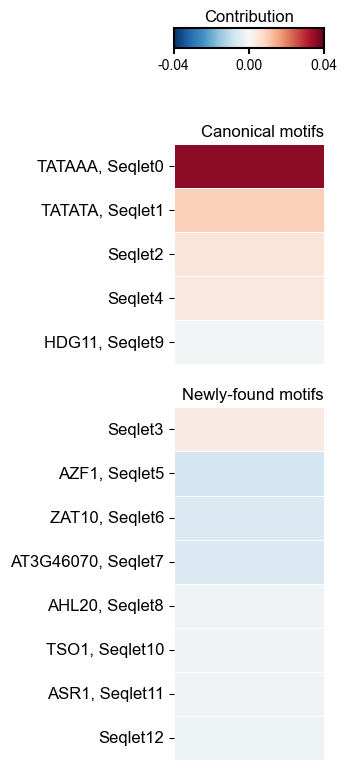

In [47]:
# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')

# Define MEME file path (used to get Motif names or order)
meme_file = "./data_for_plot/targetgan.meme"
motif_pwm_data = {}
with open(meme_file, "r") as file:
    current_motif = None
    for line in file:
        line = line.strip()
        if line.startswith("MOTIF"):
            parts = line.split()
            current_motif = parts[1]
            motif_pwm_data[current_motif] = []
        elif current_motif and line and all(c.isdigit() or c == '.' or c.isspace() for c in line):
            pwm_row = list(map(float, line.split()))
            motif_pwm_data[current_motif].append(pwm_row)

# Load contribution scores
task_to_scores = OrderedDict()
task_to_hyp_scores = OrderedDict()
f = h5py.File("./data_for_plot/contribution_scores.h5", "r")
tasks = f["contrib_scores"].keys() # 'task0'

# Read data
for task in tasks:
    task_to_scores[task] = [np.array(x) for x in f['contrib_scores'][task][:]]
    task_to_hyp_scores[task] = [np.array(x) for x in f['hyp_contrib_scores'][task][:]]

hyp_scores = np.array(task_to_hyp_scores['task0'])

# 2. Calculate Motif Contribution
over_contribution_norm = []
for motif_idx in range(13):
    motif_id = f'motif_pfm{motif_idx}'
    temp = fimo_target[fimo_target.motif_id == motif_id]
    temp.reset_index(drop=True, inplace=True)
    
    all_contri_norm = []
    
    if temp.shape[0] > 0:
        for i in range(temp.shape[0]):
            temp_sequence_name = int(temp.sequence_name[i])
            temp_start = int(temp.start[i])
            temp_stop = int(temp.stop[i])
            
            # Handle positive/negative strands
            if temp.strand[i] == '+':
                temp_hyp_scores = hyp_scores[temp_sequence_name][temp_start-1:temp_stop, :]
            else:
                temp_hyp_scores = hyp_scores[temp_sequence_name][::-1, ::-1][temp_start-1:temp_stop, :]
            
            # Calculate mean tanh contribution
            temp_contribution_norm = np.mean(np.tanh(temp_hyp_scores))
            all_contri_norm.append(temp_contribution_norm)
        
        over_contribution_norm.append(np.mean(all_contri_norm))
    else:
        over_contribution_norm.append(0.0) # If no match, set to 0

over_contribution_norm = np.array(over_contribution_norm)

# 3. Define Labels and Groups
# Full label map
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "Seqlet2",
    3: "Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ASR1, Seqlet11",
    12: "Seqlet12"
}

# Save seqlet contribution as dictionary
seqlet_contribution_dict = {label_map[i]: over_contribution_norm[i] for i in range(13)}
with open("./data_for_plot/seqlet_scores.txt", "w", encoding="utf-8") as f:
    for key, value in seqlet_contribution_dict.items():
        f.write(f"{key}: {value}\n")

# Define indices for two groups
canonical_indices = [0, 1, 2, 4, 9]
newly_found_indices = [3, 5, 6, 7, 8, 10, 11, 12]

# Prepare plot data
def get_heatmap_data(indices, scores, labels_map):
    data = scores[indices].reshape(-1, 1)
    labels = [labels_map[i] for i in indices]
    return data, labels

data_canonical, labels_canonical = get_heatmap_data(canonical_indices, over_contribution_norm, label_map)
data_new, labels_new = get_heatmap_data(newly_found_indices, over_contribution_norm, label_map)

# 4. Plotting
# Set layout: narrower figure (3 inches width), 2 rows
fig = plt.figure(figsize=(3, 8))

# Configure GridSpec with manual margins to prevent overlaps
# Left margin larger (0.45) for long Y-axis labels
# Top margin (0.85 -> 0.82) to leave MORE space for colorbar and title
gs = gridspec.GridSpec(2, 1, height_ratios=[len(canonical_indices), len(newly_found_indices)], hspace=0.15)
gs.update(left=0.45, right=0.95, top=0.82, bottom=0.05)

# Colorbar range and colormap
vmin, vmax = -0.04, 0.04
cmap = "RdBu_r" 

# Plot Upper Part (Canonical motifs)
ax1 = plt.subplot(gs[0])
sns.heatmap(data_canonical, ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax,
            annot=False, cbar=False, linewidths=0.5, linecolor='white')

# Hide outer border
for _, spine in ax1.spines.items():
    spine.set_visible(False)

ax1.set_yticklabels(labels_canonical, rotation=0, fontsize=12)
ax1.set_xticks([]) 
# Title aligned to right, slightly padded to not hit colorbar labels if any
ax1.set_title("Canonical motifs", loc='right', fontsize=12, pad=6)

# Plot Lower Part (Newly-found motifs)
ax2 = plt.subplot(gs[1])
sns.heatmap(data_new, ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax,
            annot=False, cbar=False, linewidths=0.5, linecolor='white')

# Hide outer border
for _, spine in ax2.spines.items():
    spine.set_visible(False)

ax2.set_yticklabels(labels_new, rotation=0, fontsize=12)
ax2.set_xticks([])
ax2.set_title("Newly-found motifs", loc='right', fontsize=12, pad=6)

# Shared Colorbar at the top
# Position: [left, bottom, width, height] relative to figure
# Aligned with the heatmap area (from 0.45 to 0.95, width=0.5)
# Moved bottom from 0.92 -> 0.94 to push it up
cbar_ax = fig.add_axes([0.45, 0.94, 0.5, 0.025]) 
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')

# Move title to top of colorbar to avoid clashing with "Canonical motifs"
cbar.ax.set_title("Contribution", fontsize=12, pad=5)
# Set ticks to be clean
cbar.set_ticks([vmin, 0, vmax])
cbar.ax.tick_params(labelsize=10, width=1.5, length=4, direction='out')
cbar.outline.set_linewidth(1.5)

# plt.savefig('./data_for_plot/contribution_score_combined.pdf', dpi=600) 
plt.show()

### 2. Motif Usage Fraction
Comparison of motif usage frequencies between Synthetic Promoters (SP) and Native Promoters (NP).
1.  **Calculation**: Calculates the fraction of sequences containing each motif in the synthetic dataset ($N=55,296$) versus the native dataset ($N=76,851$).
2.  **Visualization**: Displays a divergent bar chart. The left panel shows usage in Synthetic Promoters (light gray), and the right panel shows usage in Native Promoters (dark gray), allowing for direct comparison of motif enrichment.

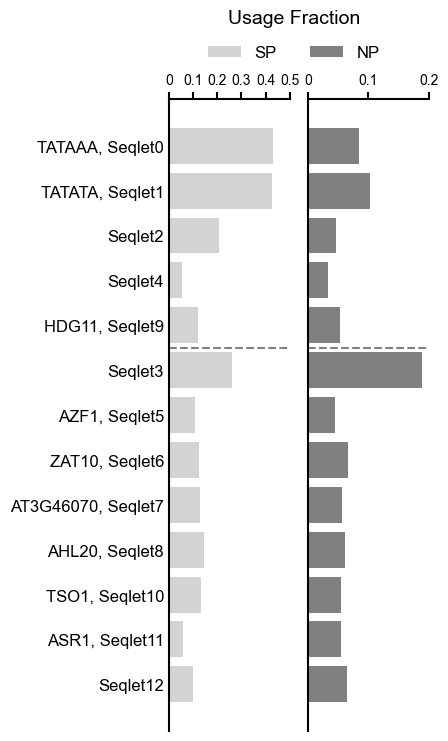

In [ ]:
# 1. Load Data
df_syn = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
df_nat = pd.read_csv('./data_for_plot/fimo_nat.tsv', sep='\t')

n_syn = 55296
n_nat = 76851

# 2. Calculate Usage Fractions
def calculate_usage_fraction(df, total_seqs, num_motifs=13):
    fractions = []
    for i in range(num_motifs):
        motif_id = f'motif_pfm{i}'
        unique_count = df[df['motif_id'] == motif_id]['sequence_name'].nunique()
        fractions.append(unique_count / total_seqs)
    return np.array(fractions)

frac_syn = calculate_usage_fraction(df_syn, n_syn)
frac_nat = calculate_usage_fraction(df_nat, n_nat)

# 3. Organize Data
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "Seqlet2",
    3: "Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ASR1, Seqlet11",
    12: "Seqlet12"
}

canonical_indices = [0, 1, 2, 4, 9]
newly_found_indices = [3, 5, 6, 7, 8, 10, 11, 12]
ordered_indices = canonical_indices + newly_found_indices

labels = [label_map[i] for i in ordered_indices]
values_syn = frac_syn[ordered_indices]
values_nat = frac_nat[ordered_indices]

# 4. Plotting
fig = plt.figure(figsize=(5, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.15)

y_pos = np.arange(len(labels))[::-1]
bar_height = 0.8

# Plot SP (Synthetic) - Left Panel
ax1 = plt.subplot(gs[0])
ax1.barh(y_pos, values_syn, height=bar_height, color='lightgray', edgecolor='none')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=12)
ax1.set_xlim(0, 0.5) 
ax1.xaxis.tick_top()

# Use custom tick labels to avoid "0.0" and ensuring clean spacing
ticks_sp = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
ax1.set_xticks(ticks_sp)
ax1.set_xticklabels(['0', '0.1', '0.2', '0.3', '0.4', '0.5'], fontsize=10)

ax1.axhline(y=7.5, color='gray', linestyle='--', linewidth=1.5)

# Set spines linewidth (matching figure 4 style)
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')
ax1.spines['bottom'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Tick Parameters
ax1.tick_params(axis='x', which='major', width=1.5, length=5, direction='out')
ax1.tick_params(axis='y', which='major', width=0, length=0) # Hide y ticks


# Plot NP (Native) - Right Panel
ax2 = plt.subplot(gs[1])
ax2.barh(y_pos, values_nat, height=bar_height, color='gray', edgecolor='none')
ax2.set_yticks([]) 
ax2.set_xlim(0, 0.2) 
ax2.xaxis.tick_top()

# Use custom tick labels to avoid "0.0" collision
ticks_np = [0, 0.1, 0.2]
ax2.set_xticks(ticks_np)
ax2.set_xticklabels(['0', '0.1', '0.2'], fontsize=10)

ax2.axhline(y=7.5, color='gray', linestyle='--', linewidth=1.5)

# Set spines linewidth (matching figure 4 style)
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(True) 

# Tick Parameters
ax2.tick_params(axis='x', which='major', width=1.5, length=5, direction='out')
ax2.tick_params(axis='y', which='major', width=0, length=0) # Hide y ticks

# Legend and Title
legend_elements = [Patch(facecolor='lightgray', edgecolor='none', label='SP'),
                   Patch(facecolor='gray', edgecolor='none', label='NP')]

leg = fig.legend(handles=legend_elements, 
           loc='lower center', 
           bbox_to_anchor=(0.63, 0.88),  # Positioned right above the plots
           ncol=2, 
           frameon=False, 
           fontsize=12,
           borderaxespad=0)

fig.text(0.63, 0.93, "Usage Fraction", ha='center', fontsize=14, va='bottom', fontweight='normal') 

# Adjust subplots top to leave space for legend and title
plt.subplots_adjust(top=0.84, left=0.38, right=0.90, bottom=0.05) 

# plt.savefig('./data_for_plot/usage_fraction.pdf', dpi=600)
plt.show()

### 3. Motif Co-occurrence Analysis
Analysis of how frequently pairs of motifs appear together in the same sequence.
1.  **Matrix Construction**: Builds binary presence/absence matrices for both SP and NP datasets and computes the co-occurrence frequency ($A^T A$).
2.  **Visualization**: Creates a combined triangular heatmap.
    *   **Lower Triangle (SP)**: Co-occurrence frequencies in Synthetic Promoters.
    *   **Upper Triangle (NP)**: Co-occurrence frequencies in Native Promoters.
    *   This layout facilitates checking if specific motif pairs are preferentially selected together (combinatorial regulation) in the generated sequences.

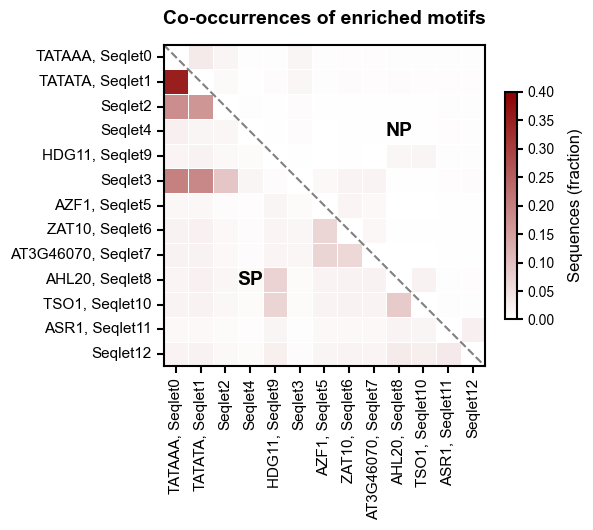

In [ ]:
# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
fimo_native = pd.read_csv('./data_for_plot/fimo_nat.tsv', sep='\t')

total_syn = 55296
total_nat = 76851

# 2. Count Motif Co-occurrences
def get_motif_counts_matrix(fimo_df, total_sequences, num_motifs=13):
    # Pre-allocate matrix
    motif_presence = np.zeros((total_sequences, num_motifs), dtype=int)
    
    # Filter out rows that are comments or invalid
    # Ensure 'motif_id' column contains strings and starts with 'motif_pfm'
    # This prevents errors if FIMO header lines are included in the CSV body
    valid_df = fimo_df[fimo_df['motif_id'].astype(str).str.startswith('motif_pfm')].copy()

    # Extract motif index
    # Safely convert to int
    valid_df['motif_idx'] = valid_df['motif_id'].apply(lambda x: int(str(x).split('motif_pfm')[-1]))
    valid_df['seq_idx'] = valid_df['sequence_name'].astype(int)
    
    # Fill matrix (vectorized assignment)
    # Filter valid indices just in case to prevent IndexErrors
    valid_rows = valid_df[(valid_df['seq_idx'] < total_sequences) & (valid_df['motif_idx'] < num_motifs)]
    motif_presence[valid_rows['seq_idx'], valid_rows['motif_idx']] = 1
            
    return motif_presence

binary_syn = get_motif_counts_matrix(fimo_target, total_syn)
binary_nat = get_motif_counts_matrix(fimo_native, total_nat)

# 3. Calculate Co-occurrence Frequencies
def get_cooccurrence_matrix(binary_matrix, total_count):
    # binary_matrix: (N, 13)
    # cooccurrence: (13, 13) = binary_matrix.T @ binary_matrix
    cooc_counts = binary_matrix.T @ binary_matrix
    # Normalize by total sequence count
    return cooc_counts / total_count

matrix_syn = get_cooccurrence_matrix(binary_syn, total_syn) # Lower triangle
matrix_nat = get_cooccurrence_matrix(binary_nat, total_nat) # Upper triangle

# 4. Construct Combined Matrix
# Label map definition
label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "Seqlet2",
    3: "Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ASR1, Seqlet11",
    12: "Seqlet12"
}

# Define indices for reordering
canonical_indices = [0, 1, 2, 4, 9]
newly_found_indices = [3, 5, 6, 7, 8, 10, 11, 12]
ordered_indices = canonical_indices + newly_found_indices
labels = [label_map[i] for i in ordered_indices]

# Reorder matrices efficiently using numpy indexing
# Create grid of new indices
idx_grid = np.ix_(ordered_indices, ordered_indices)
reordered_matrix_syn = matrix_syn[idx_grid]
reordered_matrix_nat = matrix_nat[idx_grid]

# Combine: Upper Triangle (Nat) + Lower Triangle (Syn)
# Use k=1 for upper triangle to exclude diagonal
# Use k=-1 for lower triangle to exclude diagonal
combined_matrix = np.triu(reordered_matrix_nat, k=1) + np.tril(reordered_matrix_syn, k=-1)
# Manually set the diagonal to 0
np.fill_diagonal(combined_matrix, 0) 

# 5. Plotting
fig, ax = plt.subplots(figsize=(6, 6))

colors = ["white", "darkred"]
custom_cmap = LinearSegmentedColormap.from_list("custom_bluered", colors)

# Mask diagonal visually with white
n_motifs = 13
mask = np.eye(n_motifs, dtype=bool)

# Plot Heatmap
cbar_kws = {
    "label": "Sequences (fraction)", 
    "shrink": 0.5,
}

heatmap = sns.heatmap(
    combined_matrix,
    cmap=custom_cmap,
    square=True,
    annot=False,
    cbar_kws=cbar_kws,
    vmax=0.4, 
    vmin=0.0,
    mask=mask,
    linecolor="white", 
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

# Customize Colorbar
cbar = heatmap.collections[0].colorbar
cbar.outline.set_linewidth(1.5)
cbar.outline.set_edgecolor('black')
cbar.ax.tick_params(labelsize=10, width=1.5, length=4, direction='out')
cbar.ax.set_ylabel("Sequences (fraction)", fontsize=12, labelpad=10)

# Diagonal Dashed Line
ax.plot([0, n_motifs], [0, n_motifs], ls="--", c="gray", linewidth=1.5)

# Add Text Labels "SP" and "NP"
# Coordinates (x, y) relative to data (0-12)
# SP (Lower triangle): x=3 (4th col), y=9 (10th row) -> [3.5, 9.5] centered
ax.text(3.5, 9.5, "SP", fontsize=14, fontweight='bold', ha='center', va='center')
# NP (Upper triangle): x=9 (10th col), y=3 (4th row) -> [9.5, 3.5] centered
ax.text(9.5, 3.5, "NP", fontsize=14, fontweight='bold', ha='center', va='center')

# Axis Title
ax.set_title("Co-occurrences of enriched motifs", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Set spines linewidth (matching figure 4 style)
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')
    
# Tick Parameters
ax.tick_params(axis='both', which='major', width=1.5, length=5, direction='out')

plt.tight_layout()
plt.savefig('./data_for_plot/co_occurenece.pdf', dpi=600)
plt.show()

### 4. Global Motif Distribution Heatmap
Visualizes the occurrence of enriched motifs across the entire dataset of synthetic promoters, organized by their properties.
1.  **Data Processing**: Aggregates motif counts for each sequence.
2.  **Sorting**: Sequences are sorted hierarchically: primarily by their Target expression bin (Max $\to$ Min) and secondarily by predicted Promoter Strength.
3.  **Visualization**: A large-scale heatmap showing motif density across all 55,296 sequences. Vertical bands indicate specific motifs, and the sorting reveals how motif composition changes with target experession levels.

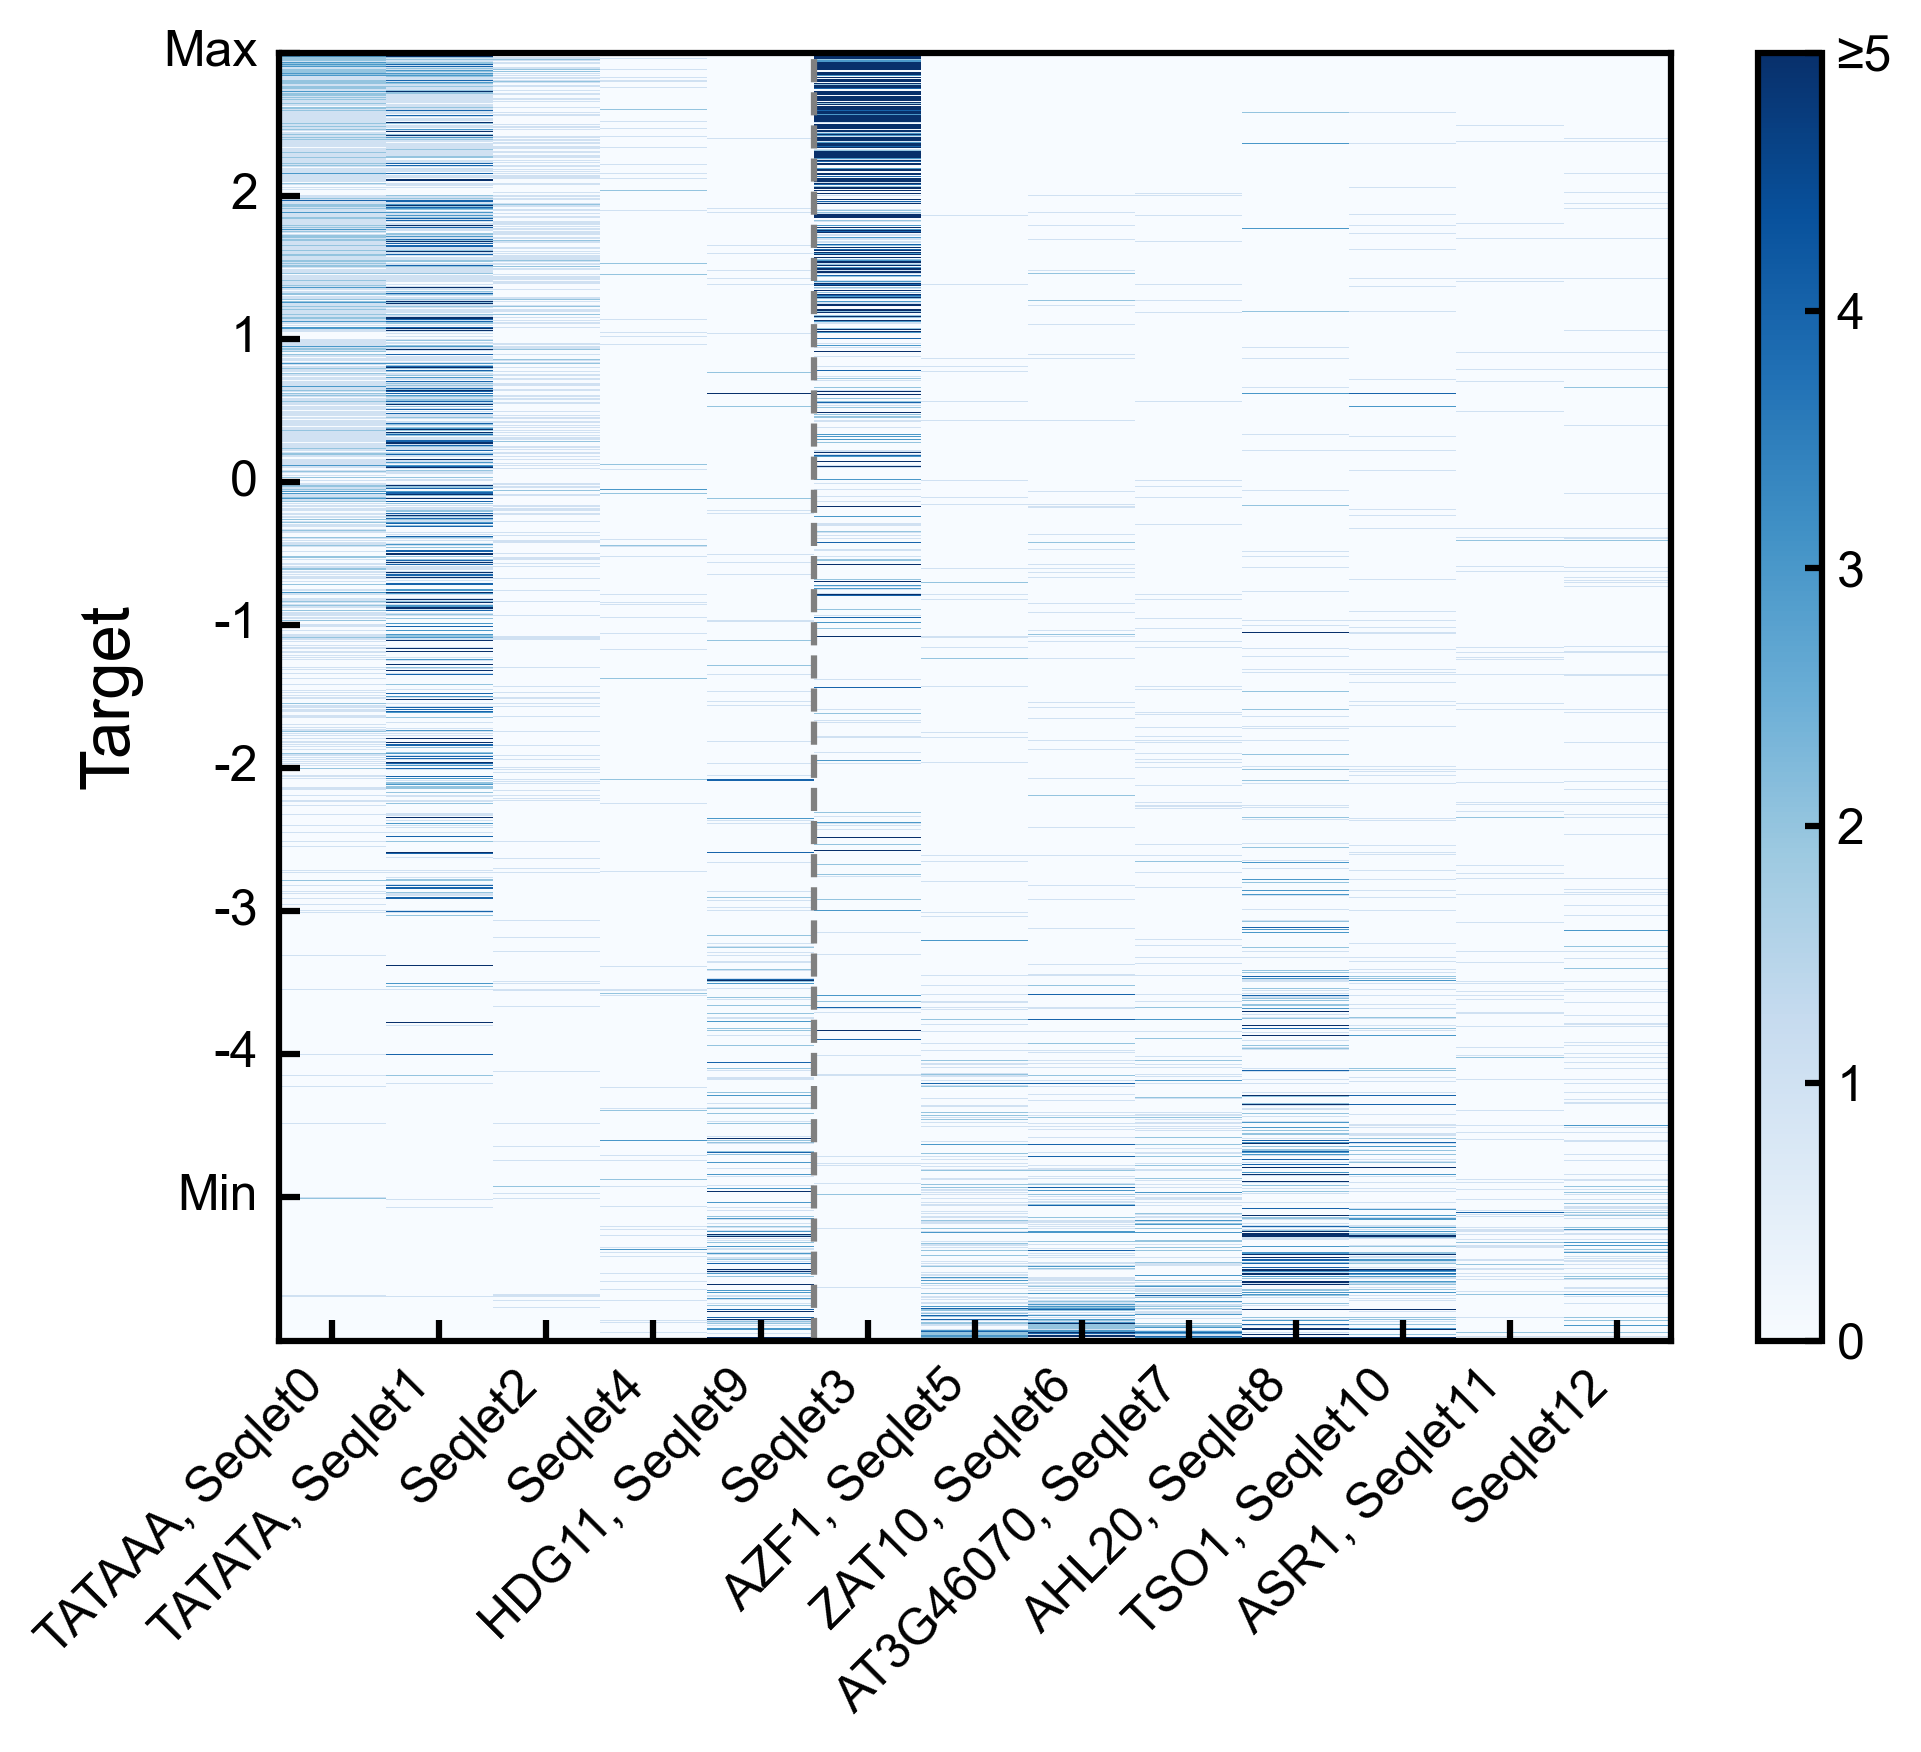

In [49]:
# 1. Load Data
fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')
excel_path = '../data/targetgan_55296.xlsx'
all_seq = pd.read_excel(excel_path)

motif_counts = pd.DataFrame(0,index=[i for i in range(55296)],columns=['seqlet_%s'%i for i in range(13)])
for i in range(272416):
    s=fimo_target['motif_id'][i].split('motif_pfm')[-1]
    motif = 'seqlet_%s'%s
    seq = int(fimo_target['sequence_name'][i])
    motif_counts[motif][seq]+=1

# Clip values > 5
motif_counts[motif_counts>5] = 5

# Create combined DataFrame
motif_counts_with_names = pd.concat([all_seq['target'], all_seq['the predicted promoter strength'], motif_counts], axis=1)

# 1. Sort Rows: Target Order (Max->Min) + Promoter Strength (High->Low)
motif_counts_with_names['target_str'] = motif_counts_with_names['target'].astype(str).str.lower()
target_order_list = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']
rank_map = {k: i for i, k in enumerate(target_order_list)}
motif_counts_with_names['target_rank'] = motif_counts_with_names['target_str'].map(rank_map).fillna(99)

motif_counts_with_names = motif_counts_with_names.sort_values(
    by=['target_rank', 'the predicted promoter strength'], 
    ascending=[True, False]
)

# 2. Reorder Columns: Specific Axis Order
desired_indices = [0, 1, 2, 4, 9, 3, 5, 6, 7, 8, 10, 11, 12]

label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "Seqlet2",
    3: "Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ASR1, Seqlet11",
    12: "Seqlet12"
}

cols_seqlet = [f'seqlet_{i}' for i in desired_indices]
# Use the sorted dataframe for plotting
plot_data = motif_counts_with_names[cols_seqlet]

x_labels = [label_map[i] for i in desired_indices]
y_labels = ['Max', '2', '1', '0', '-1', '-2', '-3', '-4', 'Min']
y_ticks = np.arange(0, 55296, 6144)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300) # Adjusted aspect ratio to be more square-like per image
# Use plot_data (sorted) instead of motif_counts (unsorted)
sns.heatmap(plot_data, cmap='Blues', ax=ax, cbar_kws={'label': ''}, vmin=0, vmax=5)

# Customize X-axis
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=12) # Changed rotation to 45

# Customize Y-axis
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, rotation=0, fontsize=12)

# Vertical Dashed Line (separating canonical and newly-found motifs, total 5 canonical)
ax.axvline(x=5, color='gray', linestyle='--', linewidth=1.5)

# Set spines linewidth (matching figure 4 style)
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Tick Parameters (ticks pointing inward based on image)
ax.tick_params(axis='both', which='major', width=1.5, length=5, direction='in', pad=5)

ax.set_ylabel('Target', fontsize=16, labelpad=5) # Increased font size
ax.set_xlabel('')

# Customize Colorbar
cbar = ax.collections[0].colorbar
cbar.outline.set_linewidth(1.5)
cbar.outline.set_edgecolor('black')
cbar.set_ticks([0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(['0', '1', '2', '3', '4', '≥5'], fontsize=12)
cbar.ax.tick_params(labelsize=12, width=1.5, length=4, direction='in')

plt.tight_layout()
plt.savefig('./data_for_plot/target_occurenece.pdf', dpi=600)
plt.show()

### 5. Single Promoter Analysis (Case Study: SP1482 & SP358)
A deep dive into specific synthetic promoter instances (SP1482 and SP358) to visualize their structure and functional elements.
1.  **Sequence Logo**: Visualizes the nucleotides using a sequence logo, highlighting the motif instances.
2.  **DeepLIFT Tracks**: Aligns the sequence with its DeepLIFT contribution scores (importance profile).
3.  **Interpretation**: By stacking these plots, we can directly link high-importance regions (peaks in the score track) to specific sequence motifs (logos), verifying that the model attends to the expected regulatory elements.

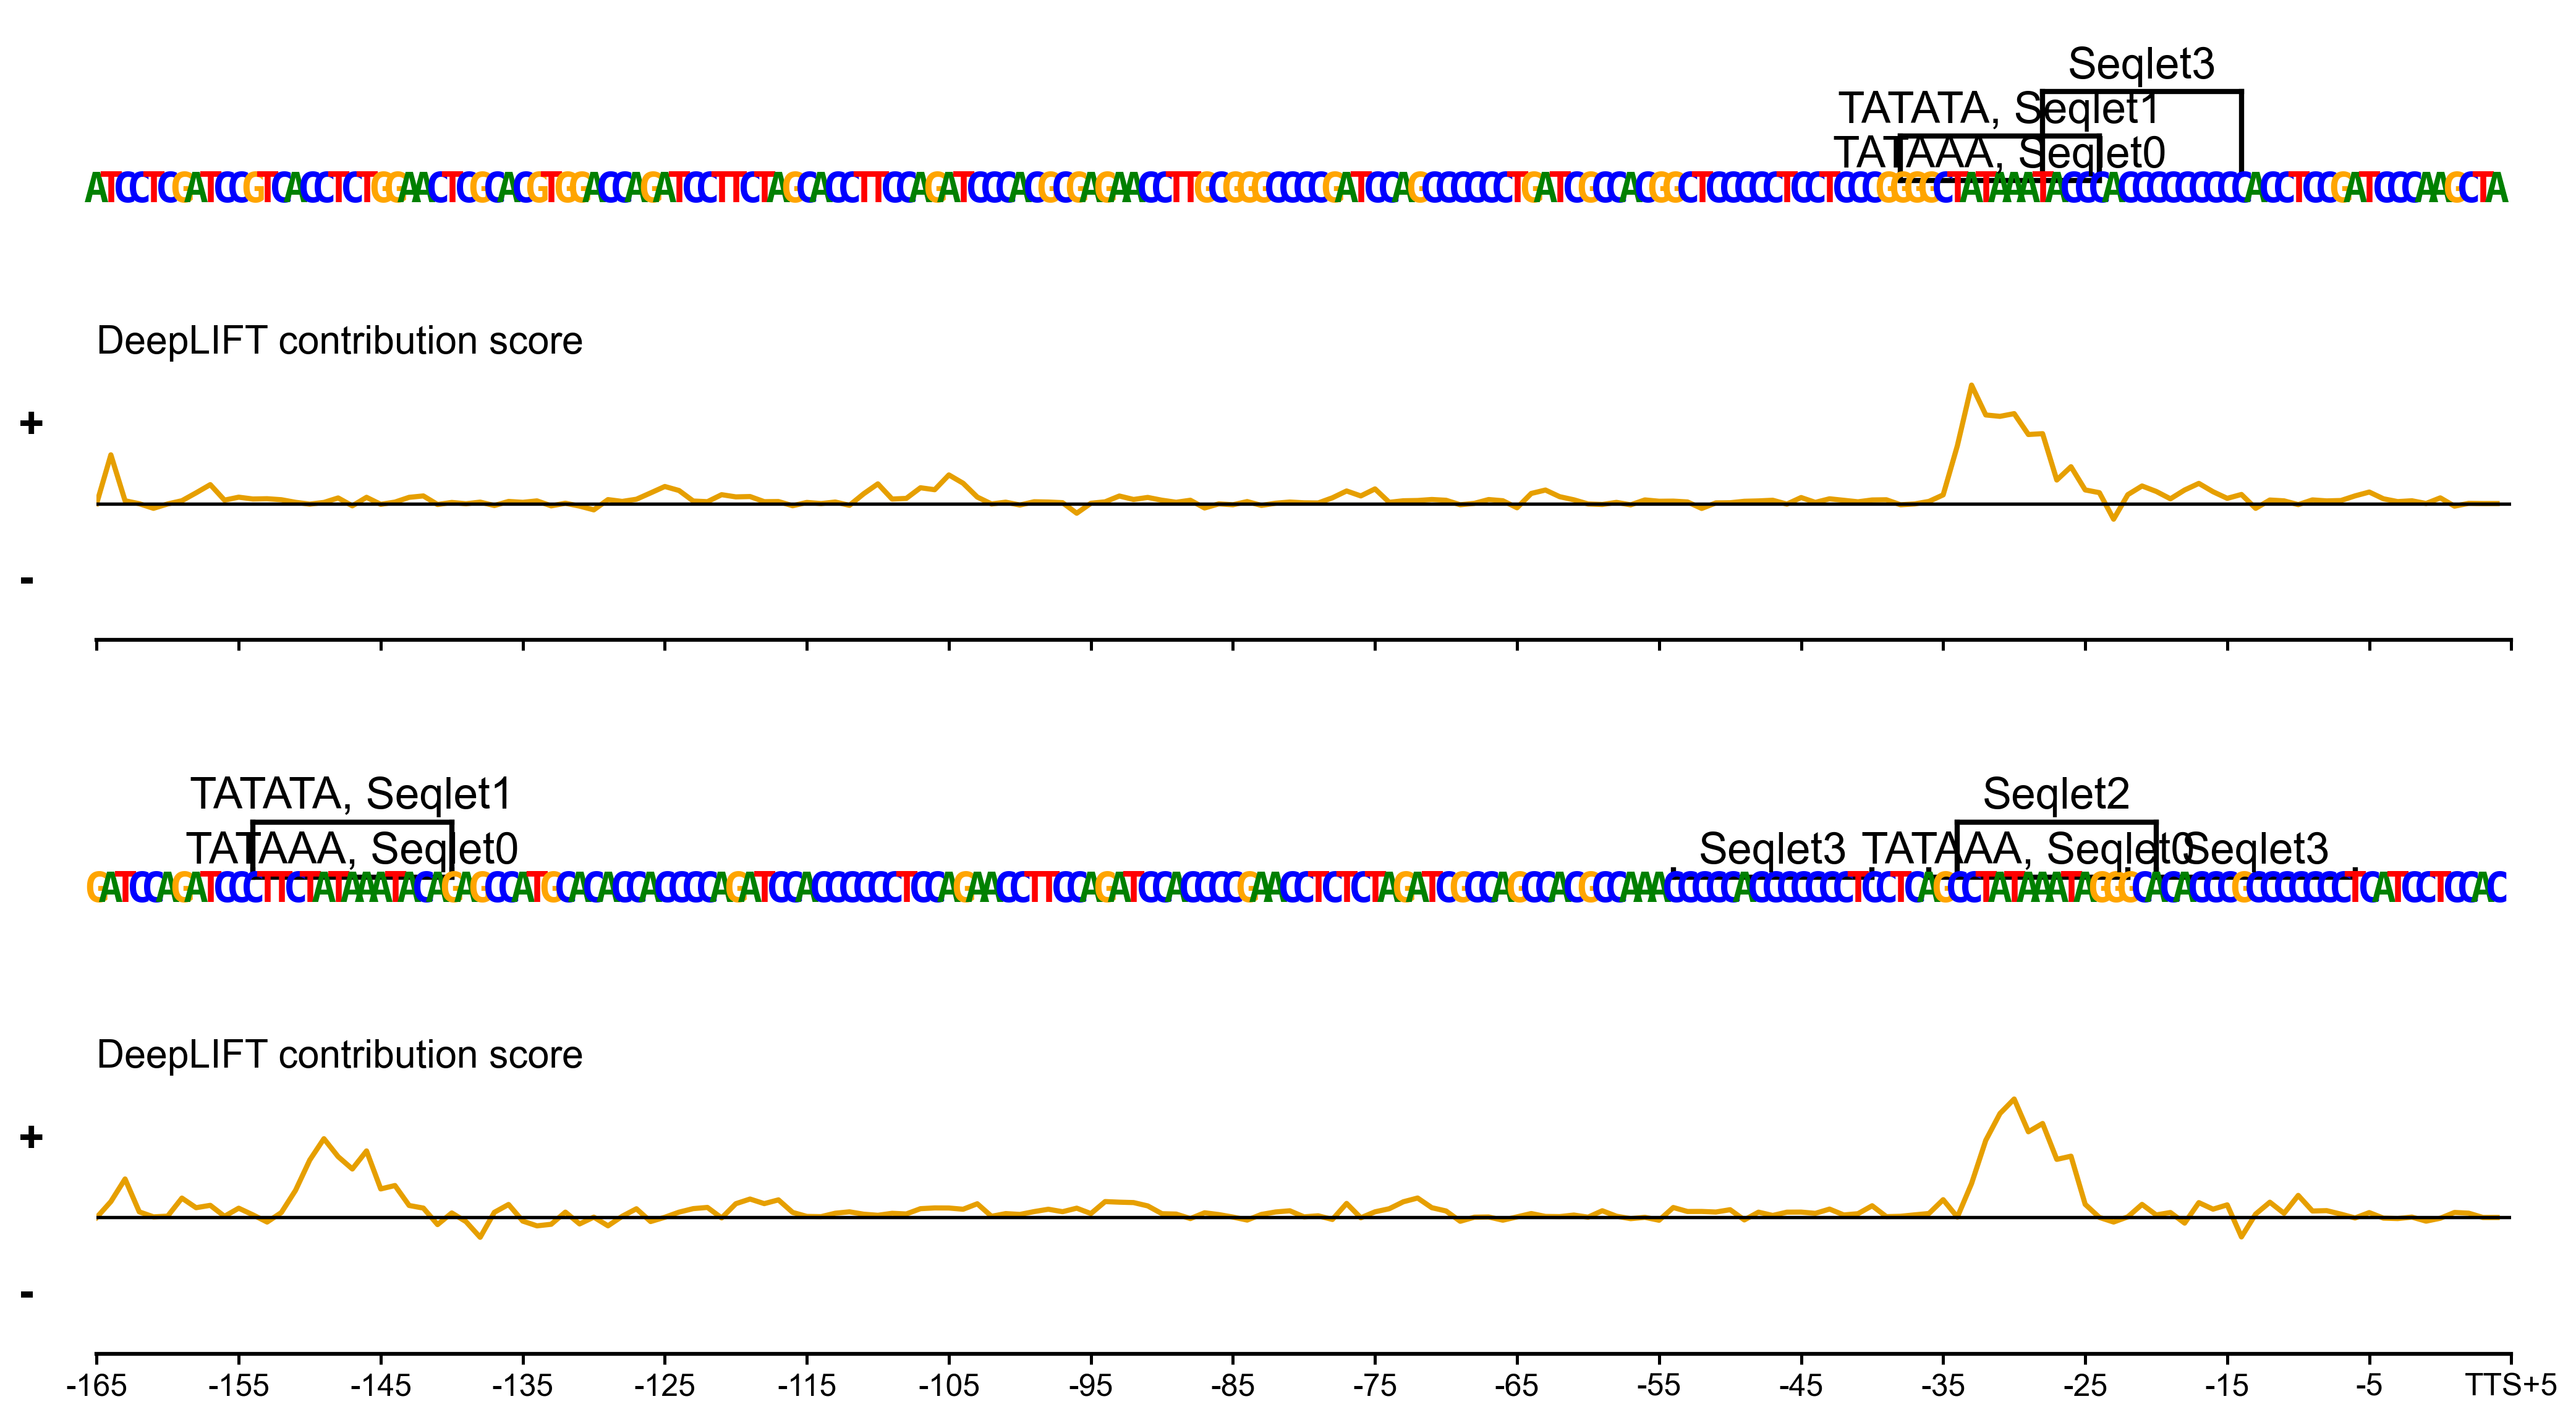

In [50]:
# 1. Setup Data
sp1482 = 'ATCCTCGATCCGTCACCTCTGGAACTCGCACGTGGACCAGATCCTTCTAGCACCTTCCAGATCCCACGCGAGAACCTTGCGGGCCCCGATCCAGCCCCCCTGATCGCCACGGCTCCCCCTCCTCCCGGGGCTATAAATACCCACCCCCCCCCACCTCCGATCCCAAGCTA'
sp358 = 'GATCCAGATCCCTTCTATAAATACAGAGCCATGCACACCACCCCAGATCCACCCCCCTCCAGAACCTTCCAGATCCACCCCGAACCTCTCTAGATCGCCAGCCACGCCAAACCCCCACCCCCCCTCCTCAGCCTATAAATAGGGCACACCCGCCCCCCCTCATCCTCCAC'

try:
    all_seq
except NameError:
    excel_path = '../data/targetgan_55296.xlsx'
    all_seq = pd.read_excel(excel_path)

# 2. Helper Functions
def to_display_x(x_index, seq_len):
    return x_index - (seq_len - 5)

def draw_sequence_letters(ax, sequence):
    base_color = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
    seq_len = len(sequence)
    for i, base in enumerate(sequence):
        x = to_display_x(i, seq_len)
        ax.text(
            x, 1.0, base,
            color=base_color.get(base, 'black'),
            fontsize=16,
            ha='center',
            va='center',
            family='monospace',
            fontweight='bold'
        )
    ax.set_xlim(-165, 5)
    ax.set_ylim(0.7, 1.7)
    ax.axis('off')

def build_motif_annotations(fimo_df, motif_name_map, keep_motif_indices=None, q_thresh=0.05, close_window=3):
    temp = fimo_df.copy()
    temp['start'] = temp['start'].astype(int) - 1
    temp['stop'] = temp['stop'].astype(int)
    temp['score'] = temp['score'].astype(float)
    temp['q-value'] = temp['q-value'].astype(float)
    temp['motif_idx'] = temp['motif_id'].astype(str).str.replace('motif_pfm', '', regex=False).astype(int)

    temp = temp[temp['q-value'] <= q_thresh].copy()
    if keep_motif_indices is not None:
        temp = temp[temp['motif_idx'].isin(keep_motif_indices)].copy()
    if temp.empty:
        return []

    temp['motif_name'] = temp['motif_idx'].map(motif_name_map).fillna(temp['motif_id'].astype(str))
    temp = temp.sort_values(by='score', ascending=False).reset_index(drop=True)

    selected = []
    for _, row in temp.iterrows():
        close_same_name = False
        for s in selected:
            same_name = s['motif_name'] == row['motif_name']
            close_region = not (row['stop'] < s['start'] - close_window or row['start'] > s['stop'] + close_window)
            if same_name and close_region:
                close_same_name = True
                break
        if not close_same_name:
            selected.append({
                'motif_name': row['motif_name'],
                'start': int(row['start']),
                'stop': int(row['stop'])
            })

    return sorted(selected, key=lambda x: x['start'])

def draw_motif_brackets(ax, motif_intervals, seq_len, level_gap=0.22, text_offset=0.02):
    if not motif_intervals:
        return

    levels = []
    for item in motif_intervals:
        lvl = 0
        while True:
            collision = False
            for (st, ed, lv) in levels:
                if lv == lvl and not (item['stop'] < st or item['start'] > ed):
                    collision = True
                    break
            if not collision:
                levels.append((item['start'], item['stop'], lvl))
                item['level'] = lvl
                break
            lvl += 1

    max_level = max(x['level'] for x in motif_intervals)
    y_top = 1.05 + (max_level + 1) * level_gap + 0.14
    ax.set_ylim(0.7, y_top)

    for item in motif_intervals:
        x0 = to_display_x(item['start'], seq_len)
        x1 = to_display_x(item['stop'], seq_len)
        y = 1.05 + item['level'] * level_gap

        ax.plot([x0, x0], [1.08, y], color='black', lw=2, clip_on=False)
        ax.plot([x1, x1], [1.08, y], color='black', lw=2, clip_on=False)
        ax.plot([x0, x1], [y, y], color='black', lw=2, clip_on=False)
        ax.text((x0 + x1) / 2, y + text_offset, item['motif_name'], ha='center', va='bottom', fontsize=17, color='black')

# 3. Load Scores
f = h5py.File('../modisco/scores.h5', 'r')
tasks = f['contrib_scores'].keys()
task_to_scores = OrderedDict()
for task in tasks:
    task_to_scores[task] = [np.array(x) for x in f['contrib_scores'][task][:]]
scores = np.array(task_to_scores['task0'])

# 4. Get Data for SP1482 & SP358
try:
    fimo_target
except NameError:
    fimo_target = pd.read_csv('./data_for_plot/fimo_target_seq.tsv', sep='\t')

seq_idx_1482 = int(all_seq[all_seq.sequence == sp1482].index[0])
seq_idx_358 = int(all_seq[all_seq.sequence == sp358].index[0])

# Filter FIMO data for these sequences（按你给的写法）
fimo_sp358 = fimo_target[fimo_target['sequence_name'] == int(seq_idx_358)]
fimo_sp1482 = fimo_target[fimo_target['sequence_name'] == int(seq_idx_1482)]

label_map = {
    0: "TATAAA, Seqlet0",
    1: "TATATA, Seqlet1",
    2: "Seqlet2",
    3: "Seqlet3",
    4: "Seqlet4",
    5: "AZF1, Seqlet5",
    6: "ZAT10, Seqlet6",
    7: "AT3G46070, Seqlet7",
    8: "AHL20, Seqlet8",
    9: "HDG11, Seqlet9",
    10: "TSO1, Seqlet10",
    11: "ASR1, Seqlet11",
    12: "Seqlet12"
}
motif_name_map = {i: label_map[i] for i in label_map}
motifs_1482 = build_motif_annotations(fimo_sp1482, motif_name_map, keep_motif_indices=list(label_map.keys()))
motifs_358 = build_motif_annotations(fimo_sp358, motif_name_map, keep_motif_indices=list(label_map.keys()))

score_track_1482 = np.sum(scores[seq_idx_1482], axis=1)
score_track_358 = np.sum(scores[seq_idx_358], axis=1)

# 5. Plotting
fig, axes = plt.subplots(
    4, 1, figsize=(14, 8), dpi=300, sharex=True,
    gridspec_kw={'height_ratios': [1.1, 1.4, 1.1, 1.4], 'hspace': 0.35}
 )
ax1, ax2, ax3, ax4 = axes

# --- SP1482 Top ---
draw_sequence_letters(ax1, sp1482)
draw_motif_brackets(ax1, motifs_1482, len(sp1482))

# --- SP1482 Bottom ---
x_1482 = np.arange(len(score_track_1482)) - (len(score_track_1482) - 5)
ax2.plot(x_1482, score_track_1482, color='#E69F00', linewidth=2.0)
ax2.axhline(y=0, color='black', linewidth=1.3)
ax2.set_xlim(-165, 5)
ax2.set_yticks([])
ax2.spines['left'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='x', which='major', width=1.2, length=4, direction='out')
y_lim_1482 = max(abs(score_track_1482.min()), abs(score_track_1482.max()))
ax2.set_ylim(-y_lim_1482 * 1.15, y_lim_1482 * 1.35)
ax2.text(-170.5, y_lim_1482 * 0.65, '+', fontsize=17, fontweight='bold', va='center')
ax2.text(-170.5, -y_lim_1482 * 0.65, '-', fontsize=17, fontweight='bold', va='center')
ax2.text(-165, y_lim_1482 * 1.2, 'DeepLIFT contribution score', fontsize=15, ha='left', va='bottom')

# --- SP358 Top ---
draw_sequence_letters(ax3, sp358)
draw_motif_brackets(ax3, motifs_358, len(sp358))

# --- SP358 Bottom ---
x_358 = np.arange(len(score_track_358)) - (len(score_track_358) - 5)
ax4.plot(x_358, score_track_358, color='#E69F00', linewidth=2.0)
ax4.axhline(y=0, color='black', linewidth=1.3)
ax4.set_xlim(-165, 5)
ax4.set_yticks([])
ax4.spines['left'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.tick_params(axis='x', which='major', width=1.2, length=4, direction='out')
y_lim_358 = max(abs(score_track_358.min()), abs(score_track_358.max()))
ax4.set_ylim(-y_lim_358 * 1.15, y_lim_358 * 1.35)
ax4.text(-170.5, y_lim_358 * 0.65, '+', fontsize=17, fontweight='bold', va='center')
ax4.text(-170.5, -y_lim_358 * 0.65, '-', fontsize=17, fontweight='bold', va='center')
ax4.text(-165, y_lim_358 * 1.2, 'DeepLIFT contribution score', fontsize=15, ha='left', va='bottom')

ticks = np.arange(-165, 6, 10)
tick_labels = [str(v) for v in ticks]
if tick_labels:
    tick_labels[-1] = 'TTS+5'
ax4.set_xticks(ticks)
ax4.set_xticklabels(tick_labels, fontsize=12)

plt.subplots_adjust(left=0.06, right=0.99, top=0.98, bottom=0.08)
plt.savefig('./data_for_plot/single_promoter_analysis.pdf', dpi=600)
plt.show()

### 6. Ultra-High Activity Sequences Feature Analysis
In this section, we analyze the subset of sequences exhibiting ultra-high experimental activity (`log2(experimental activity, average) > 5.19`).

1. **Filtering**: Extract Ultra-High Activity Synthetic Promoters (SPs) from the STARR-seq experimental results.
2. **Motif Extraction**: Parse FIMO motif discovery results to calculate the occurrence frequencies of each motif within these ultra-high activity sequences.
3. **Motif Distribution Heatmap**: Visualize the distribution of discovered motifs across the filtered ultra-high activity sequences.
4. **Co-occurrence Heatmap**: Generate a comparative motif co-occurrence heatmap plotting the motif connection fraction. The upper triangle represents Ultra-high-activity SPs, while the lower triangle indicates the baseline across all SPs.

#### 6.1 Filtering

In [87]:
starr_seq_result = pd.read_excel('/home/xlxiang/TargetGAN-main/data/STARR_seq.xlsx', header=2)
starr_seq_result = starr_seq_result[starr_seq_result['Coefficient of Variation (CV %)'] <= 30]
SP = starr_seq_result[starr_seq_result['name'].str.contains('SP')].copy()
ultra_high_activity = SP[SP['log2(experimental activity, average)'] > 5.19].copy()
ultra_high_activity.sort_values(by='log2(experimental activity, average)', ascending=False, inplace=True)
ultra_high_activity.reset_index(drop=True, inplace=True)

#Optional: Export ultra-high activity sequences to a FASTA file
with open('/home/xlxiang/TargetGAN-main/data_for_plot/ultra_high_activity.fa', 'w') as f:
    for _, row in ultra_high_activity.iterrows():
        f.write(f">{row['name']}\n{row['sequence']}\n")

#### 6.2 Motif Extraction

In [88]:
# Read FIMO results, skipping any trailing summary lines that might not have 'motif_id'
fimo_ultra_high = pd.read_csv('/home/xlxiang/TargetGAN-main/data_for_plot/fimo_ultra_high.tsv', sep='\t')
fimo_ultra_high = fimo_ultra_high.dropna(subset=['motif_id', 'sequence_name']).copy()

# Extract seqlet index directly to form the motif name (e.g., 'seqlet_0')
fimo_ultra_high['motif'] = 'seqlet_' + fimo_ultra_high['motif_id'].str.split('motif_pfm').str[-1]

# Cross-tabulate sequence name and motif to get the occurrences matrix
motif_counts_ultra_high = pd.crosstab(fimo_ultra_high['sequence_name'], fimo_ultra_high['motif'])

# Reindex to ensure all 13 seqlets and all ultra-high sequences are included properly
expected_columns = [f'seqlet_{i}' for i in range(13)]
motif_counts_ultra_high = motif_counts_ultra_high.reindex(
    index=ultra_high_activity['name'].tolist(), 
    columns=expected_columns, 
    fill_value=0
)

#### 6.3 Motif Distribution Heatmap

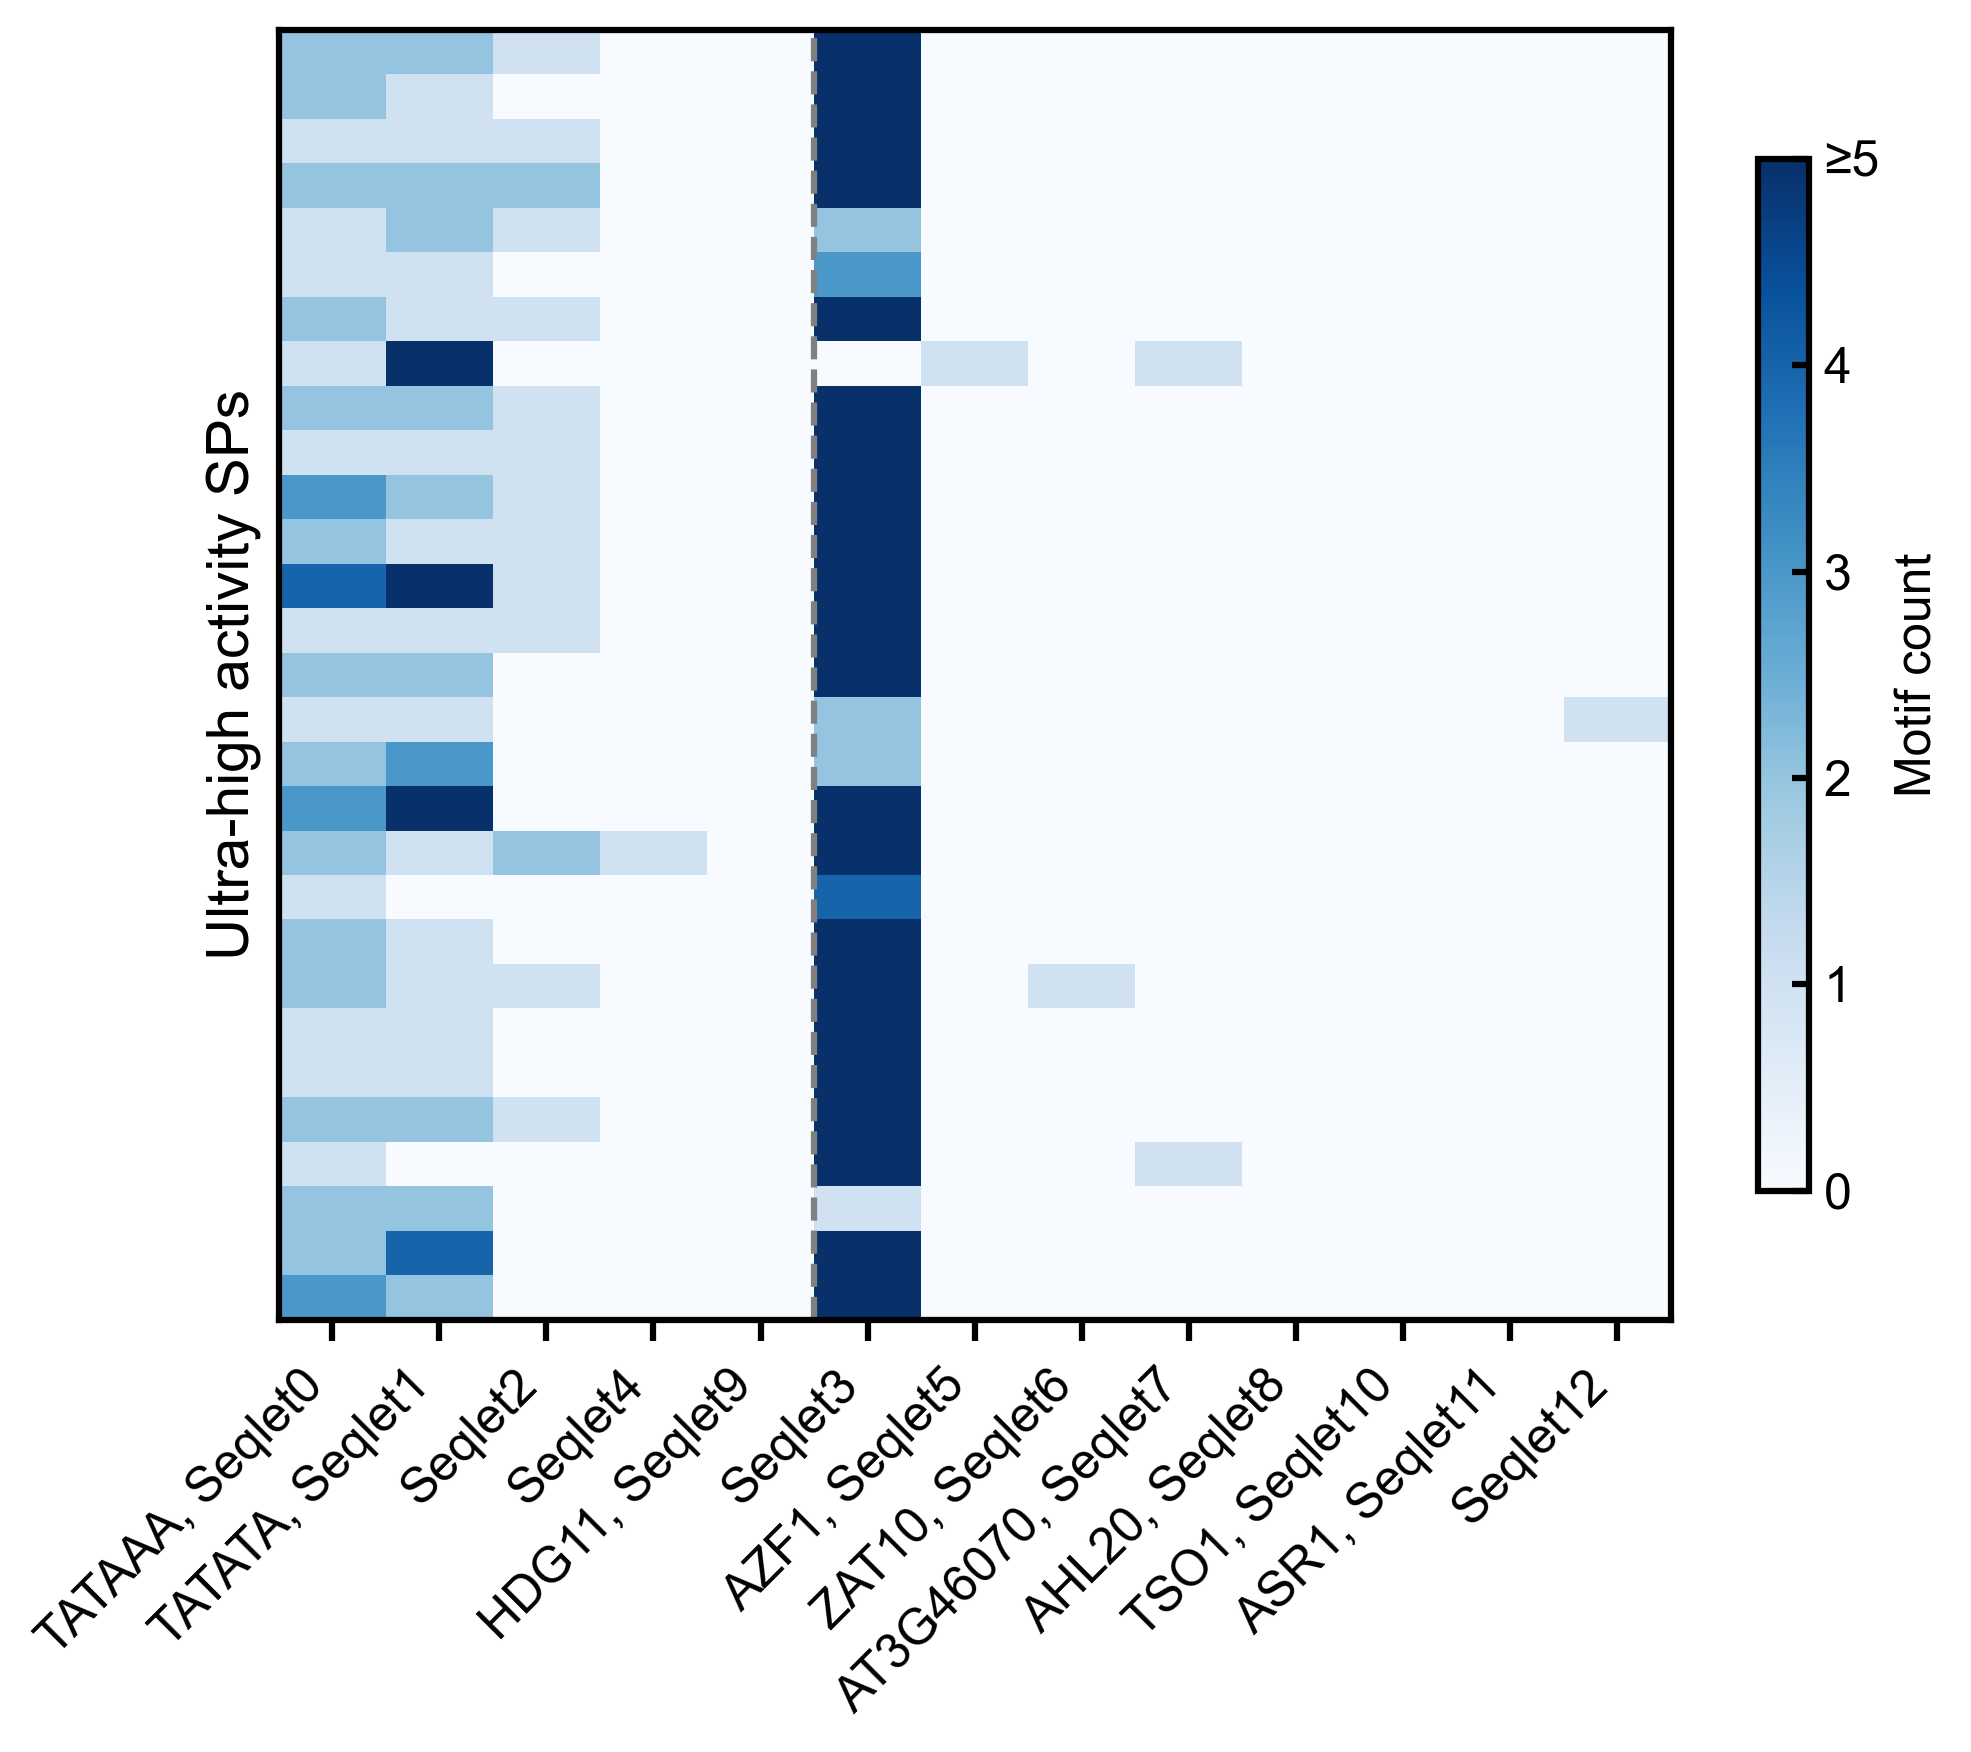

In [93]:
# Prepare plot data, clip values greater than 5 for better color scaling
plot_data = motif_counts_ultra_high.clip(upper=5).copy()

# 1. Reorder Columns to match previous motif analysis configurations
desired_indices = [0, 1, 2, 4, 9, 3, 5, 6, 7, 8, 10, 11, 12]
label_map = {
    0: "TATAAA, Seqlet0", 1: "TATATA, Seqlet1", 2: "Seqlet2", 4: "Seqlet4", 9: "HDG11, Seqlet9",
    3: "Seqlet3", 5: "AZF1, Seqlet5", 6: "ZAT10, Seqlet6", 7: "AT3G46070, Seqlet7", 
    8: "AHL20, Seqlet8", 10: "TSO1, Seqlet10", 11: "ASR1, Seqlet11", 12: "Seqlet12"
}

cols_seqlet = [f'seqlet_{i}' for i in desired_indices]
x_labels = [label_map[i] for i in desired_indices]
plot_data = plot_data[cols_seqlet]

fig, ax = plt.subplots(figsize=(7, 6), dpi=300) 

# Generate the Heatmap 
# Using cbar_kws to style the colorbar similarly to previous heatmaps
sns.heatmap(
    plot_data, 
    cmap='Blues', 
    ax=ax, 
    cbar=True, 
    cbar_kws={'label': 'Motif count', 'shrink': 0.8},
    vmin=0, 
    vmax=5
)

# Customize the Colorbar Ticks
cbar = ax.collections[0].colorbar
cbar.outline.set_linewidth(1.5)
cbar.outline.set_edgecolor('black')
cbar.set_ticks([0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(['0', '1', '2', '3', '4', '≥5'], fontsize=12)
cbar.ax.tick_params(labelsize=12, width=1.5, length=4, direction='in')

# Refine X-axis and Y-axis Appearance
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticks([]) # Hide Y-axis labels
ax.set_ylabel('Ultra-high activity SPs', fontsize=14) # Informative Y-axis label
ax.set_xlabel('')

# Vertical Dashed Line separating canonical and newly-found motifs
ax.axvline(x=5, color='gray', linestyle='--', linewidth=1.5)

# Format the borders (Spines) & Tick appearances
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.tick_params(axis='x', which='major', width=1.5, length=5, direction='out', pad=5)
ax.tick_params(axis='y', which='major', width=0, length=0)

plt.tight_layout()
plt.savefig('./data_for_plot/ultra_high_motif_distribution.pdf', dpi=600)
plt.show()

#### 6.4 Co-occurrence Heatmap

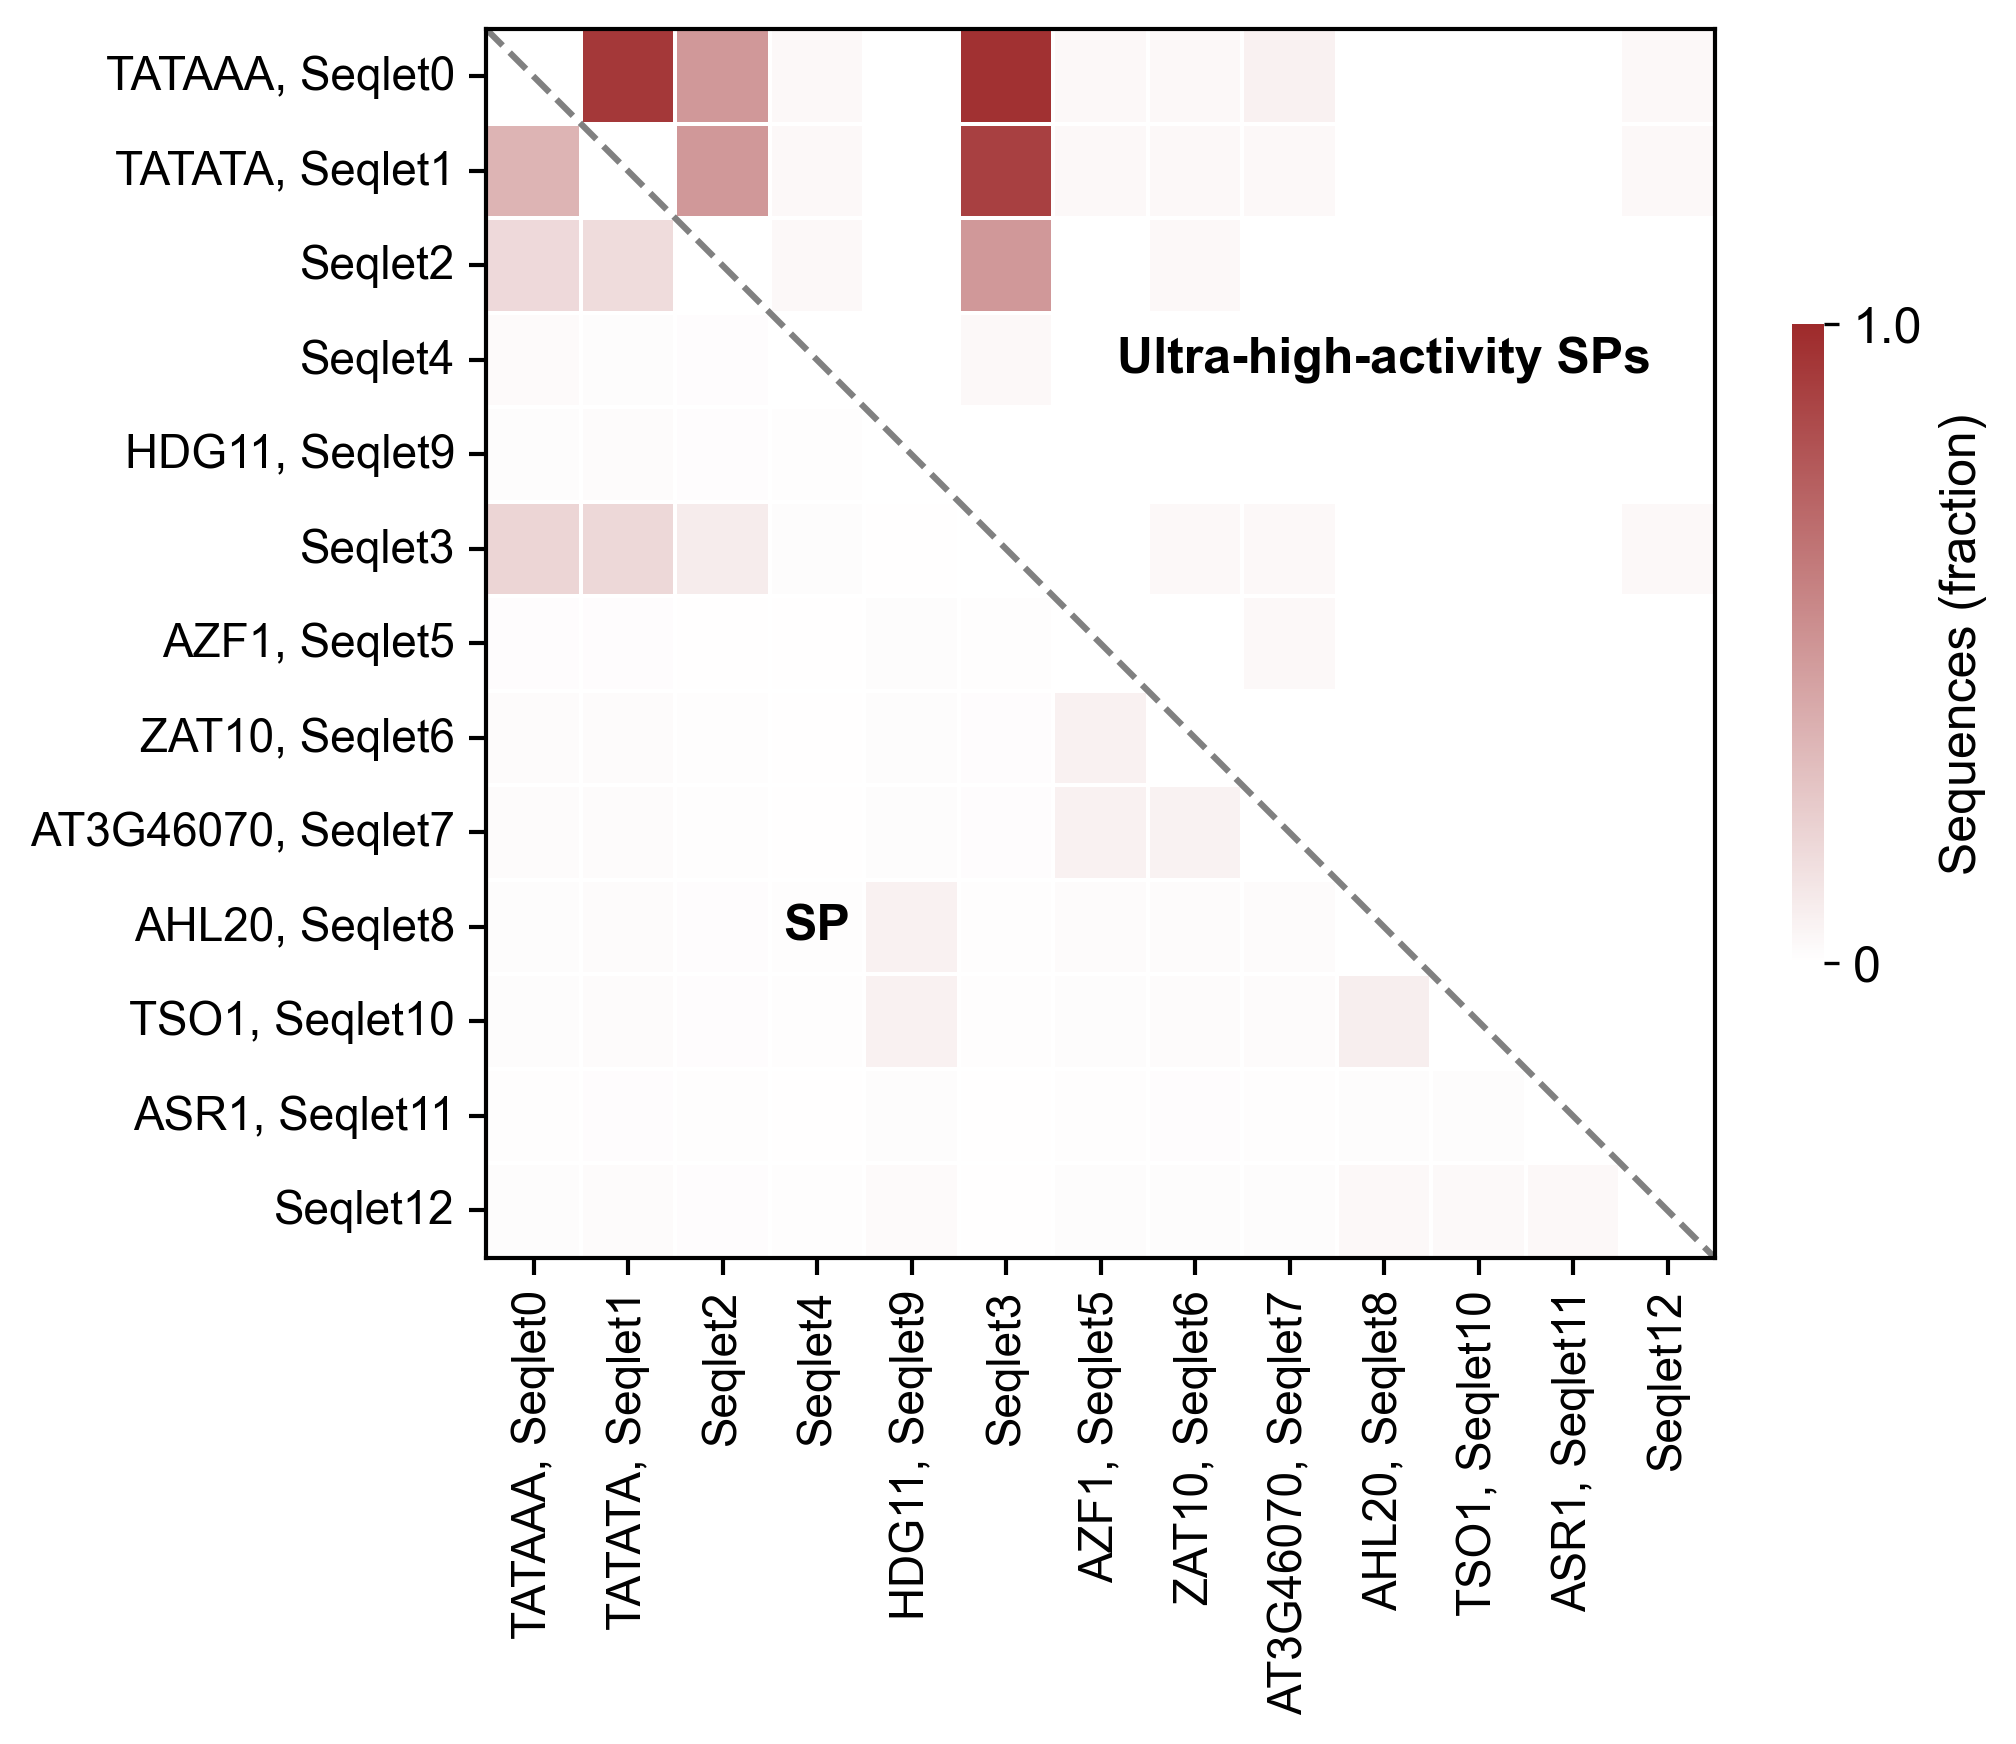

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 1. Prepare Data
# Uses `binary_syn` from an earlier cell for all SP baseline
cols = [f'seqlet_{i}' for i in range(13)]
binary_ultra = (motif_counts_ultra_high[cols] > 0).astype(int).values

total_sp = binary_syn.shape[0]        # Baseline count for all SPs
total_ultra = binary_ultra.shape[0]   # Count for Ultra-high SPs

# 2. Function to Calculate Co-occurrence Fraction
def get_cooccurrence_matrix(binary_matrix, total_count):
    # binary_matrix: (N, 13)
    # cooccurrence: (13, 13) = binary_matrix.T @ binary_matrix
    cooc_counts = binary_matrix.T @ binary_matrix
    # Normalize by total sequence count
    return cooc_counts / total_count

matrix_sp = get_cooccurrence_matrix(binary_syn, total_sp)
matrix_ultra = get_cooccurrence_matrix(binary_ultra, total_ultra)

# 3. Label Definition and Subsetting (Matching Previous Visualizations)
desired_indices = [0, 1, 2, 4, 9, 3, 5, 6, 7, 8, 10, 11, 12]
label_map = {
    0: "TATAAA, Seqlet0", 1: "TATATA, Seqlet1", 2: "Seqlet2", 4: "Seqlet4", 9: "HDG11, Seqlet9",
    3: "Seqlet3", 5: "AZF1, Seqlet5", 6: "ZAT10, Seqlet6", 7: "AT3G46070, Seqlet7", 
    8: "AHL20, Seqlet8", 10: "TSO1, Seqlet10", 11: "ASR1, Seqlet11", 12: "Seqlet12"
}

ordered_labels = [label_map[i] for i in desired_indices]

# Reorder matrices based on desired axis indices
idx_grid = np.ix_(desired_indices, desired_indices)
reordered_matrix_sp = matrix_sp[idx_grid]
reordered_matrix_ultra = matrix_ultra[idx_grid]

# 4. Construct Upper/Lower Triangular Combined Matrix
# Lower triangle: Baseline SP (inclusive of diagonal)
# Upper triangle: Ultra-high SP (exclusive of diagonal)
# Use k=1 for upper triangle to exclude diagonal
# Use k=-1 for lower triangle to exclude diagonal
combined_matrix = np.triu(reordered_matrix_ultra, k=1) + np.tril(reordered_matrix_sp, k=-1)
# Manually fill the diagonal with 0 to ensure the center diagonal is masked properly
np.fill_diagonal(combined_matrix, 0)

# 5. Plotting Configurations
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
custom_cmap = LinearSegmentedColormap.from_list("custom_whitered", ["white", "#9E2A2B"])

# Mask diagonal
n_motifs = 13
mask = np.eye(n_motifs, dtype=bool)

# Generate Co-occurrence Heatmap
cbar_kws = {
    "label": "Sequences (fraction)", 
    "shrink": 0.5,
    "ticks": [0, 1.0]
}

feature_heatmap = sns.heatmap(
    combined_matrix, 
    cmap=custom_cmap, 
    square=True, 
    annot=False,
    vmax=1.0, 
    vmin=0.0, 
    mask=mask,
    cbar=True,
    cbar_kws=cbar_kws,
    linewidths=0.5, 
    linecolor='white',
    xticklabels=ordered_labels, 
    yticklabels=ordered_labels, 
    ax=ax
)

# Refine Custom Colorbar format
cbar = feature_heatmap.collections[0].colorbar
cbar.outline.set_visible(False)
cbar.ax.set_yticklabels(['0', '1.0'])
cbar.set_label("Sequences (fraction)", size=12)

# Aesthetic Tweaks
# Draw central diagonal dividing line
ax.plot([0, n_motifs], [0, n_motifs], ls="--", c="gray", linewidth=1.5)

# Append Contextual Labels
ax.text(3.5, 9.5, "SP", fontsize=12, fontweight='bold', ha='center', va='center')
ax.text(9.5, 3.5, "Ultra-high-activity SPs", fontsize=12, fontweight='bold', ha='center', va='center')

plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Format Axes Spines
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', width=1.0, length=4, direction='out')

plt.tight_layout()
plt.savefig('./data_for_plot/ultra_high_vs_sp_cooccurrence.pdf', dpi=600)
plt.show()